In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from rosetta_db import get_sqlite_dbcon
db_con = get_sqlite_dbcon(parent="WT")
df = pd.read_sql("select * from docked_scores", db_con)
#df = pd.read_sql("select * from relaxed_scores", db_con)

In [3]:
df["dist_wt"] = df.variant.str.count("\.") + 1

In [4]:
df.head()

,total_score,Grid_score,Transform_accept_ratio,angle_constraint,atom_pair_constraint,chainbreak,classic_grid_X,coordinate_constraint,dihedral_constraint,dslf_ca_dih,...,interface_delta_X,ligand_is_touching_X,omega,p_aa_pp,pro_close,ref,total_score_X,description,variant,dist_wt
0,-877.100,-31.0,0.706,0.0,0.0,0.0,-26.0,0.983,0.0,0.0,...,-7.346,1.0,48.260,-39.465,1.092,-45.15,-26.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0052,D157G.I71V.R172H.F152L.I38V.Q233R.F261L.V38I.R48C,9
1,-883.151,-30.0,0.744,0.0,0.0,0.0,-27.0,1.257,0.0,0.0,...,-6.493,1.0,49.442,-41.111,1.257,-42.55,-27.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0042,D157G,1
2,-878.427,-29.0,0.660,0.0,0.0,0.0,-29.0,0.909,0.0,0.0,...,-11.721,1.0,49.369,-39.094,1.197,-40.34,-29.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0077,D157G.I71V.R172H.N65D,4
3,-877.227,-31.0,0.708,0.0,0.0,0.0,-28.0,0.860,0.0,0.0,...,-10.863,1.0,48.495,-40.860,1.263,-42.99,-28.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0087,D157G.I71V.R172H.F152L,4
4,-872.393,-29.0,0.810,0.0,0.0,0.0,-28.0,0.660,0.0,0.0,...,-10.795,1.0,48.900,-41.013,1.196,-45.85,-28.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_0080,D157G.I71V.R172H.F152L.I38V.Q233R.F261L,7


In [5]:
campaign1_muts = [
    'D157G.I71V.R172H.F152L.I38V.Q233R.F261L',
    'D157G.I71V.R172H.F152L.I38V.Q233R.F261L.V38I.R48C',
    'D157G.I71V.R172H.F152L',
    'D157G.I71V.R172H.N65D',
    'D157G.I71V.R172H',
    'D157G.I71V',
    'D157G'
]

In [6]:
df["variant_type"] = pd.Categorical(df.variant.isin(campaign1_muts)).rename_categories(["random", "campaign1"])
df_random = df[df.variant_type == "random"]
df_campaign1 = df[df.variant_type == "campaign1"]

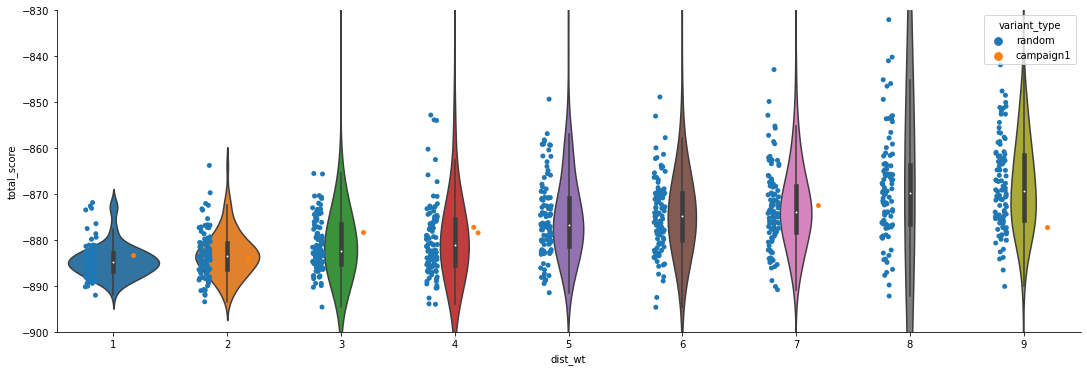

In [7]:
#sns.catplot(y="total_score", x="dist_wt", data=df, aspect=3, kind="box")
#plt.figure(figsize=(12, 4))
g = sns.catplot(y="total_score", x="dist_wt", kind="violin", data=df_random, aspect=3, alpha=0.4)
sns.stripplot(y="total_score", x="dist_wt", hue="variant_type",
              data=df, ax=g.ax, dodge=True)


plt.ylim(bottom=-900, top=-830)
plt.subplots_adjust()